# Results 1: EIT Localisation Notebook

This notebook loads the press dataset, cleans the target/EIT columns, subtracts paired baseline readings from contact readings, and trains localisation models to predict x/y target position from EIT channels.

## Workflow

1. Load the raw CSV and inspect the data shape.
2. Clean metadata columns and re-centre target coordinates.
3. Subtract baseline EIT readings from their paired contact readings.
4. Sample 10 spatially ordered target locations along a corner-to-corner diagonal and compare their EIT profiles with a correlation matrix.
5. Build train/test splits from contact rows only.
6. Scale features and fit a linear regression baseline.
7. Compare several localisation models and review diagnostic plots.


## 1. Imports and Display Defaults


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")


## 2. Load the Raw Data

Set the CSV path, read the file, and do a quick shape/head inspection before modifying anything.


In [2]:
csv_file_path = 'RawData/Press_1027/2026-06-12_12-59-23_6Forces_40x10.csv'

In [3]:
try:
    df = pd.read_csv(csv_file_path)
    print("CSV file loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file at '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

CSV file loaded successfully!


In [4]:
df.shape

(48001, 219)

In [5]:
df.head()

,row_type,measurement_index,target_x_mm,target_y_mm,target_force_N,actual_x_mm,actual_y_mm,position_time_s,actual_force_N,force_time_s,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,...,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207,eit_time_s
0,baseline,NaN,NaN,NaN,NaN,NaN,NaN,0.267163,NaN,NaN,0.03830,0.02458,0.01528,0.01146,0.000599,0.004249,0.004944,0.005336,0.006212,0.007194,0.006755,0.006553,0.008666,0.02587,0.01652,0.01200,0.000104,0.004006,0.004587,0.005201,0.005900,0.006969,0.006413,0.006350,0.008280,0.01442,0.02216,0.01766,0.000534,0.003879,0.004644,0.005297,0.006066,0.007026,0.006544,0.006407,0.008484,0.01439,0.03834,0.02418,0.006329,0.001478,0.002113,0.003441,0.004515,0.006512,0.005359,0.005399,0.006264,0.001514,...,0.006570,0.006442,0.005162,0.003695,0.001065,0.003204,0.003835,0.01553,0.000561,0.006678,0.006421,0.006478,0.005442,0.005378,0.005131,0.005216,0.000964,0.000704,0.000695,0.003268,0.000750,0.006561,0.006199,0.006423,0.005303,0.005319,0.005153,0.005426,0.001408,0.001022,0.000988,0.002810,0.01375,0.008511,0.008282,0.008397,0.006244,0.006289,0.004892,0.005154,0.001188,0.001064,0.000964,0.000849,0.01210,0.01535,0.01464,0.01467,0.001584,0.002065,0.002562,0.001791,0.004264,0.004386,0.004999,0.005152,0.005979,0.000605,0.000869,0.267163
1,baseline,1.0,60.923077,22.772080,1.5,60.92,22.77,17.802742,0.0000,NaN,0.03831,0.02446,0.01520,0.01144,0.000707,0.004167,0.004909,0.005528,0.006266,0.007349,0.006726,0.006504,0.008623,0.02581,0.01662,0.01206,0.000160,0.003916,0.004550,0.005221,0.005878,0.006977,0.006534,0.006297,0.008315,0.01438,0.02231,0.01780,0.000561,0.003915,0.004726,0.005437,0.006162,0.007118,0.006624,0.006396,0.008346,0.01437,0.03829,0.02410,0.006277,0.001581,0.002128,0.003488,0.004545,0.006661,0.005379,0.005378,0.006162,0.001699,...,0.006675,0.006472,0.005267,0.003602,0.001217,0.003463,0.003989,0.01546,0.000655,0.006578,0.006511,0.006508,0.005364,0.005423,0.005160,0.005242,0.001027,0.001036,0.000938,0.003386,0.000761,0.006527,0.006324,0.006425,0.005402,0.005434,0.005282,0.005468,0.001352,0.001050,0.001054,0.003018,0.01370,0.008636,0.008313,0.008430,0.006293,0.006424,0.005041,0.005265,0.001225,0.001298,0.001174,0.000652,0.01207,0.01548,0.01473,0.01467,0.001618,0.001911,0.002479,0.001781,0.004307,0.004321,0.004789,0.005184,0.006035,0.000651,0.000845,18.003346
2,contact,1.0,60.923077,22.772080,1.5,60.92,22.77,17.802742,1.5463,25.026540,0.03835,0.02453,0.01528,0.01148,0.000772,0.004400,0.004954,0.005431,0.005983,0.007130,0.006512,0.006329,0.008466,0.02583,0.01663,0.01209,0.000220,0.003885,0.004654,0.005156,0.005681,0.006821,0.006236,0.006124,0.008179,0.01463,0.02236,0.01772,0.000375,0.003725,0.004572,0.005306,0.005850,0.006896,0.006302,0.006177,0.008132,0.01474,0.03850,0.02430,0.006329,0.001645,0.002188,0.003587,0.004433,0.006491,0.005458,0.005440,0.006153,0.001715,...,0.006622,0.006371,0.005331,0.003622,0.000834,0.003013,0.003117,0.01501,0.001150,0.006472,0.006266,0.006296,0.005557,0.005437,0.005512,0.005458,0.001013,0.000752,0.000717,0.002770,0.001291,0.006343,0.006163,0.006220,0.005351,0.005447,0.005511,0.005705,0.001471,0.001141,0.001079,0.002258,0.01360,0.008423,0.008068,0.008205,0.006246,0.006138,0.004995,0.005391,0.001353,0.000991,0.000976,0.000746,0.01219,0.01488,0.01487,0.01495,0.001781,0.002188,0

## 3. Clean Columns and Coordinates

Drop timing/force columns that are not model inputs, then shift target x/y into the working coordinate frame.


In [6]:
# Keep the target location and EIT channels used by the localisation models.
cols_to_exclude = [
    "target_force_N",
    "actual_x_mm",
    "actual_y_mm",
    "position_time_s",
    "force_time_s",
    "eit_time_s",
]
df = df.drop(columns=cols_to_exclude, errors="ignore")


In [7]:
# Re-centre target positions around the sensor/contact coordinate frame.
df.loc[:, "target_x_mm"] = df["target_x_mm"].values - 48
df.loc[:, "target_y_mm"] = df["target_y_mm"].values - 9


In [8]:
# Drop the first row so the remaining data starts on a baseline/contact pair.
df = df.drop(index=0).reset_index(drop=True)
df.head()


,row_type,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,baseline,1.0,12.923077,13.772080,0.0000,0.03831,0.02446,0.01520,0.01144,0.000707,0.004167,0.004909,0.005528,0.006266,0.007349,0.006726,0.006504,0.008623,0.02581,0.01662,0.01206,0.000160,0.003916,0.004550,0.005221,0.005878,0.006977,0.006534,0.006297,0.008315,0.01438,0.02231,0.01780,0.000561,0.003915,0.004726,0.005437,0.006162,0.007118,0.006624,0.006396,0.008346,0.01437,0.03829,0.02410,0.006277,0.001581,0.002128,0.003488,0.004545,0.006661,0.005379,0.005378,0.006162,0.001699,0.02449,0.02587,0.007231,0.000768,0.001555,...,0.007074,0.006675,0.006472,0.005267,0.003602,0.001217,0.003463,0.003989,0.01546,0.000655,0.006578,0.006511,0.006508,0.005364,0.005423,0.005160,0.005242,0.001027,0.001036,0.000938,0.003386,0.000761,0.006527,0.006324,0.006425,0.005402,0.005434,0.005282,0.005468,0.001352,0.001050,0.001054,0.003018,0.01370,0.008636,0.008313,0.008430,0.006293,0.006424,0.005041,0.005265,0.001225,0.001298,0.001174,0.000652,0.01207,0.01548,0.01473,0.01467,0.001618,0.001911,0.002479,0.001781,0.004307,0.004321,0.004789,0.005184,0.006035,0.000651,0.000845
1,contact,1.0,12.923077,13.772080,1.5463,0.03835,0.02453,0.01528,0.01148,0.000772,0.004400,0.004954,0.005431,0.005983,0.007130,0.006512,0.006329,0.008466,0.02583,0.01663,0.01209,0.000220,0.003885,0.004654,0.005156,0.005681,0.006821,0.006236,0.006124,0.008179,0.01463,0.02236,0.01772,0.000375,0.003725,0.004572,0.005306,0.005850,0.006896,0.006302,0.006177,0.008132,0.01474,0.03850,0.02430,0.006329,0.001645,0.002188,0.003587,0.004433,0.006491,0.005458,0.005440,0.006153,0.001715,0.02445,0.02573,0.007345,0.000603,0.001800,...,0.006890,0.006622,0.006371,0.005331,0.003622,0.000834,0.003013,0.003117,0.01501,0.001150,0.006472,0.006266,0.006296,0.005557,0.005437,0.005512,0.005458,0.001013,0.000752,0.000717,0.002770,0.001291,0.006343,0.006163,0.006220,0.005351,0.005447,0.005511,0.005705,0.001471,0.001141,0.001079,0.002258,0.01360,0.008423,0.008068,0.008205,0.006246,0.006138,0.004995,0.005391,0.001353,0.000991,0.000976,0.000746,0.01219,0.01488,0.01487,0.01495,0.001781,0.002188,0.002606,0.001786,0.004551,0.004741,0.005212,0.005104,0.006022,0.000914,0.001287
2,baseline,2.0,19.384615,15.521368,0.0000,0.03833,0.02467,0.01522,0.01141,0.000471,0.004085,0.004962,0.005556,0.006292,0.007231,0.006730,0.006559,0.008570,0.02587,0.01652,0.01209,0.000266,0.003910,0.004646,0.005101,0.005915,0.007141,0.006507,0.006303,0.008366,0.01439,0.02229,0.01773,0.000303,0.003805,0.004539,0.005302,0.006198,0.007144,0.006597,0.006419,0.008348,0.01441,0.03836,0.02428,0.006344,0.001783,0.002286,0.003623,0.004626,0.006588,0.005559,0.005463,0.006295,0.001617,0.02447,0.02584,0.007382,0.000701,0.001698,...,0.007050,0.006603,0.006515,0.005223,0.003645,0.001284,0.003331,0.003637,0.01541,0.000638,0.006666,0.006539,0.006552,0.005478,0.005422,0.005269,0.005281,0.000984,0.000734,0.000534,0.003383,0.000956,0.006588,0.006287,0.006468,0.005428,0.005538,0.005284,0.005587,0.001329,0.000886,0.000973,0.002973,0.01382,0.008700,0.008359,0.008428,0.006316,0.006291,0.004964,0.005308,0.001251,0.000930,0.000749,0.000753,0.01222,0.01548,0.01461,0.

## 4. Baseline Subtraction

Each baseline row is paired with the following contact row. The EIT channels in each contact row are replaced with `contact - baseline`, which reduces drift before modelling.


In [9]:
# Subtract each baseline row from the following contact row for EIT channels only.
eit_cols = df.columns[df.columns.str.startswith("eit_")].tolist()
if not eit_cols:
    raise ValueError("No columns starting with 'eit_' were found.")

if len(df) % 2 != 0:
    raise ValueError(f"Expected baseline/contact pairs, but df has an odd number of rows: {len(df)}")

row_types = df["row_type"].astype(str).str.strip().str.lower()
baseline_ok = row_types.iloc[0::2].eq("baseline").to_numpy()
contact_ok = row_types.iloc[1::2].eq("contact").to_numpy()
print(f"Baseline rows OK: {baseline_ok.all()}, Contact rows OK: {contact_ok.all()}")

if not (baseline_ok.all() and contact_ok.all()):
    bad_pair = next(i for i, ok in enumerate(baseline_ok & contact_ok) if not ok)
    raise ValueError(
        "row_type must alternate baseline/contact. "
        f"First bad pair starts at row {2 * bad_pair}: "
        f"{row_types.iloc[2 * bad_pair]!r}, {row_types.iloc[2 * bad_pair + 1]!r}"
    )

baseline_idx = df.index[0::2]
measurement_idx = df.index[1::2]

df_subtracted = df.copy()
df_subtracted.loc[measurement_idx, eit_cols] = (
    df.loc[measurement_idx, eit_cols].to_numpy(dtype=float)
    - df.loc[baseline_idx, eit_cols].to_numpy(dtype=float)
)
df_subtracted = df_subtracted.drop(columns="row_type", errors="ignore")
df_subtracted.head()


Baseline rows OK: True, Contact rows OK: True


,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,eit_55,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,1.0,12.923077,13.772080,0.0000,0.03831,0.02446,0.01520,0.01144,0.000707,0.004167,0.004909,0.005528,0.006266,0.007349,0.006726,0.006504,0.008623,0.02581,0.01662,0.01206,0.000160,0.003916,0.004550,0.005221,0.005878,0.006977,0.006534,0.006297,0.008315,0.01438,0.02231,0.01780,0.000561,0.003915,0.004726,0.005437,0.006162,0.007118,0.006624,0.006396,0.008346,0.01437,0.03829,0.02410,0.006277,0.001581,0.002128,0.003488,0.004545,0.006661,0.005379,0.005378,0.006162,0.001699,0.02449,0.02587,0.007231,0.000768,0.001555,0.003070,...,0.007074,0.006675,0.006472,0.005267,0.003602,0.001217,0.003463,0.003989,0.01546,0.000655,0.006578,0.006511,0.006508,0.005364,0.005423,0.005160,0.005242,0.001027,0.001036,0.000938,0.003386,0.000761,0.006527,0.006324,0.006425,0.005402,0.005434,0.005282,0.005468,0.001352,0.001050,0.001054,0.003018,0.01370,0.008636,0.008313,0.008430,0.006293,0.006424,0.005041,0.005265,0.001225,0.001298,0.001174,0.000652,0.01207,0.01548,0.01473,0.01467,0.001618,0.001911,0.002479,0.001781,0.004307,0.004321,0.004789,0.005184,0.006035,0.000651,0.000845
1,1.0,12.923077,13.772080,1.5463,0.00004,0.00007,0.00008,0.00004,0.000065,0.000233,0.000045,-0.000097,-0.000283,-0.000219,-0.000214,-0.000175,-0.000157,0.00002,0.00001,0.00003,0.000060,-0.000031,0.000104,-0.000065,-0.000197,-0.000156,-0.000298,-0.000173,-0.000136,0.00025,0.00005,-0.00008,-0.000186,-0.000190,-0.000154,-0.000131,-0.000312,-0.000222,-0.000322,-0.000219,-0.000214,0.00037,0.00021,0.00020,0.000052,0.000064,0.000060,0.000099,-0.000112,-0.000170,0.000079,0.000062,-0.000009,0.000016,-0.00004,-0.00014,0.000114,-0.000165,0.000245,-0.000055,...,-0.000184,-0.000053,-0.000101,0.000064,0.000020,-0.000383,-0.000450,-0.000872,-0.00045,0.000495,-0.000106,-0.000245,-0.000212,0.000193,0.000014,0.000352,0.000216,-0.000014,-0.000284,-0.000221,-0.000616,0.000530,-0.000184,-0.000161,-0.000205,-0.000051,0.000013,0.000229,0.000237,0.000119,0.000091,0.000025,-0.000760,-0.00010,-0.000213,-0.000245,-0.000225,-0.000047,-0.000286,-0.000046,0.000126,0.000128,-0.000306,-0.000198,0.000093,0.00012,-0.00060,0.00014,0.00028,0.000163,0.000277,0.000127,0.000005,0.000244,0.000420,0.000423,-0.000080,-0.000013,0.000263,0.000442
2,2.0,19.384615,15.521368,0.0000,0.03833,0.02467,0.01522,0.01141,0.000471,0.004085,0.004962,0.005556,0.006292,0.007231,0.006730,0.006559,0.008570,0.02587,0.01652,0.01209,0.000266,0.003910,0.004646,0.005101,0.005915,0.007141,0.006507,0.006303,0.008366,0.01439,0.02229,0.01773,0.000303,0.003805,0.004539,0.005302,0.006198,0.007144,0.006597,0.006419,0.008348,0.01441,0.03836,0.02428,0.006344,0.001783,0.002286,0.003623,0.004626,0.006588,0.005559,0.005463,0.006295,0.001617,0.02447,0.02584,0.007382,0.000701,0.001698,0.003074,...,0.007050,0.006603,0.006515,0.005223,0.003645,0.001284,0.003331,0.003637,0.01541,0.000638,0.006666,0.006539,0.006552,0.005478,0.005422,0.005269,0.005281,0.000984,0.000734,0.000534,0.003383,0.000956,0.006588,0.006287,0.006468,0.005428,0.005538,0.005284,0.005587,0.001329,0.000886,0.000973,0.002973,0.01382,0.008700,0.008359,0.008428,0.006316,0.006291,0.004964,0.005308,0.

In [10]:
# Keep contact rows for modelling; baseline rows have already served as drift references.
df_model = df_subtracted.loc[measurement_idx].reset_index(drop=True)
df_shuffled = df_model.sample(frac=1, random_state=5).reset_index(drop=True)
df_shuffled.head()


,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,eit_55,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,13460.0,43.615385,16.615385,1.3083,0.00161,0.00121,0.00134,0.00043,0.000243,-0.000104,0.000244,-0.000012,0.000179,0.000333,0.000567,0.000309,0.000459,0.00113,0.00122,0.00015,0.000125,0.000010,0.000310,0.000175,0.000308,0.000320,0.000370,0.000476,0.000504,0.00106,0.00017,-0.00123,-0.000019,0.000131,0.000354,0.000350,0.000310,0.000846,0.001079,0.000880,0.001075,0.00137,0.00161,-0.00263,-0.000640,0.000342,0.000488,0.000435,0.000541,0.000618,0.000910,0.000692,0.000878,0.001435,0.00119,0.00123,0.000018,-0.000415,-0.000198,0.000742,...,0.001292,0.001240,0.004148,0.004417,5.940000e-04,0.000879,-0.000422,-0.001045,-0.00085,-0.000047,0.000742,0.000791,0.001306,0.001446,0.004001,0.004046,0.000196,0.000469,0.000324,0.000565,-0.000484,-0.000052,0.000579,0.000660,0.001215,0.001162,0.003796,0.003708,0.000412,0.000487,0.000393,0.000777,-0.000375,-0.00107,0.000851,0.000805,0.001341,0.001339,0.004181,0.003959,0.000059,0.000627,0.000218,0.000832,0.000272,-0.00105,-0.00115,0.00094,0.00151,0.001315,0.002956,-0.000684,-0.000165,-0.000004,0.000029,-0.000012,0.000209,-0.000323,-0.000054,-0.000080
1,17868.0,9.692308,4.170940,1.7638,-0.00032,-0.00064,-0.00070,0.00029,0.000492,-0.000256,-0.000296,-0.000096,0.001636,0.002172,0.001918,0.001890,-0.002494,-0.00068,-0.00073,0.00047,0.000736,-0.000431,-0.000397,-0.000270,0.001297,0.001908,0.002345,0.002371,-0.002092,0.00225,-0.00087,0.00032,0.000835,-0.000480,-0.000431,-0.000234,0.001415,0.001839,0.002429,0.002352,-0.002219,0.00210,-0.00031,0.00325,0.003407,-0.000275,-0.000997,-0.000839,0.000384,0.001713,0.001163,0.001182,-0.000523,0.000496,-0.00063,-0.00066,0.003557,0.001388,0.000362,-0.000679,...,0.001930,0.001674,0.001721,0.001841,1.335000e-03,-0.000936,-0.001213,0.000145,0.00032,0.004928,0.001790,0.002284,0.002287,0.001266,0.001184,0.001257,0.001371,0.001567,0.001303,0.000066,0.000578,0.004910,0.001899,0.002369,0.002307,0.001156,0.001200,0.001482,0.001411,0.001353,0.001346,0.000210,0.000495,0.00420,-0.002484,-0.002269,-0.002170,-0.000608,-0.000643,0.000774,0.000367,0.002643,0.002481,0.001703,-0.000204,0.00166,0.00042,0.00201,0.00220,0.000557,0.000516,-0.000948,0.000043,0.000557,0.000499,0.000877,0.002725,0.004088,0.004957,0.004835
2,13047.0,51.692308,13.088319,0.7783,0.00163,0.00087,0.00056,-0.00075,-0.000471,0.001067,0.000991,0.000912,0.000647,0.000166,0.000662,0.000659,0.000732,0.00087,0.00070,-0.00074,-0.000713,0.001087,0.001067,0.000845,0.000675,0.000243,0.000736,0.000751,0.000998,0.00143,0.00018,-0.00135,-0.000636,0.001296,0.001140,0.001130,0.000800,0.000759,0.001370,0.001113,0.001498,0.00173,0.00171,-0.00299,-0.001095,0.000979,0.000906,0.001130,0.000872,0.000868,0.000863,0.001082,0.001307,0.001814,0.00100,0.00091,-0.001373,-0.000482,0.001035,0.001172,...,0.000361,0.000072,-0.000036,0.000239,-7.580000e-04,-0.000185,0.001374,0.000728,-0.00187,-0.000035,0.000487,0.000614,0.000920,0.000341,0.000179,-0.000022,-0.000996,-0.001894,-0.002045,-0.000846,0.000914,-0.000058,0.000570,0.000462,0.000803,0.000397,0.000060,0.000025,-0.001019,-0.001889,-0.001827,-0.000942,0.000868,-0.00240,0.000787,0.000654,

In [11]:
df_model.describe()

,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,eit_55,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,...,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,12000.500000,31.500000,9.000000,3.420624,-0.000875,-0.000952,-0.000812,-0.000965,0.000003,0.000010,-0.000042,-0.000069,-0.000038,-0.000095,-0.000416,-0.000411,-0.000583,-0.000976,-0.000833,-0.001010,-0.000212,0.000027,-0.000023,-0.000054,-0.000034,-0.000096,-0.000397,-0.000393,-0.000509,0.000354,-0.001043,-0.001217,-0.000297,0.000042,-0.000012,-0.000054,-0.000040,-0.000126,-0.000439,-0.000433,-0.000554,0.000324,-0.000879,-0.001358,-0.000586,0.000232,0.000152,0.000050,0.000029,-0.000085,-0.000259,-0.000258,-0.000361,0.000143,-0.000953,-0.000977,-0.000631,0.000292,0.000255,0.000108,...,-0.000130,-0.000085,-0.000087,-0.000042,0.000109,0.000202,-0.000071,-0.000143,-0.000946,0.000356,-0.000417,-0.000398,-0.000437,-0.000256,-0.000265,-0.000171,-0.000123,0.000276,0.000188,0.000263,-0.000362,0.000327,-0.000411,-0.000393,-0.000431,-0.000256,-0.000263,-0.000170,-0.000116,0.000244,0.000177,0.000262,-0.000304,-0.000459,-0.000584,-0.000510,-0.000555,-0.000358,-0.000369,-0.000342,-0.000296,0.000276,0.000173,0.000201,0.000109,-0.000378,-0.000943,0.000343,0.000312,0.000145,0.000151,0.000244,0.000233,0.000145,0.000128,0.000135,0.000240,0.000328,0.000351,0.000323
std,6928.347566,18.647413,5.120345,1.707302,0.002469,0.002126,0.001934,0.001861,0.000857,0.001071,0.001032,0.001045,0.001259,0.001312,0.001029,0.001006,0.001036,0.002157,0.001960,0.001897,0.000934,0.001057,0.001017,0.001025,0.001228,0.001281,0.001017,0.000995,0.000995,0.001107,0.002380,0.002307,0.001005,0.001075,0.001034,0.001044,0.001

## 5. Diagonal Location Correlation Matrix

Subsample 10 target locations along the bottom-left to top-right diagonal of the observed target grid, keep their corresponding baseline-subtracted EIT profiles, and calculate the Pearson correlation between locations. If a location has repeated measurements, its EIT profile is averaged before calculating correlations.


Diagonal target locations used for nearest-neighbour subsampling:


,target_x_mm,target_y_mm
0,0.0,0.0
1,7.0,2.0
2,14.0,4.0
3,21.0,6.0
4,28.0,8.0
5,35.0,10.0
6,42.0,12.0
7,49.0,14.0
8,56.0,16.0
9,63.0,18.0


Selected measured target locations:


,target_x_mm,target_y_mm
0,0.000000,0.000000
1,6.461538,2.159544
2,14.538462,4.256410
3,21.000000,6.222222
4,27.461538,8.096866
5,35.538462,9.874644
6,42.000000,11.555556
7,48.461538,14.803419
8,56.538462,16.205128
9,63.000000,16.000000


Corresponding EIT profiles preview:


,target_x_mm,target_y_mm,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9
0,0.000000,0.000000,0.000489,0.000778,0.000774,0.000762,0.000188,-0.000081,-0.000069,-0.000068,-0.000538,-0.000485
1,6.461538,2.159544,0.000145,0.000260,0.000218,0.000329,0.000162,-0.000233,-0.000178,-0.000176,0.000505,0.000501
2,14.538462,4.256410,0.000156,-0.000279,-0.000265,-0.000299,-0.000068,-0.000211,-0.000109,-0.000018,0.002121,0.002180
3,21.000000,6.222222,-0.000521,-0.000590,-0.000564,-0.000520,-0.000411,0.000372,0.000547,0.000493,0.001014,0.000927
4,27.461538,8.096866,-0.000677,-0.000744,-0.000668,-0.000770,-0.000633,0.000758,0.000786,0.000747,-0.000231,-0.000274
5,35.538462,9.874644,-0.000691,-0.000743,-0.000884,-0.001103,-0.000349,-0.000002,-0.000164,-0.000257,-0.000302,-0.000339
6,42.000000,11.555556,-0.000647,-0.000817,-0.000897,-0.001133,-0.000094,-0.000027,-0.000128,-0.000196,-0.000054,-0.000172
7,48.461538,14.803419,0.000855,0.000371,0.000686,0.000320,-0.000170,0.000281,0.000232,0.000268,0.000329,0.000241
8,56.538462,16.205128,0.002959,0.002366,0.001959,0.001096,0.000234,0.000496,0.000480,0.000634,0.000688,0.000927
9,63.000000,16.000000,0.001133,0.000394,0.001718,0.000621,0.001117,0.000070,0.000194,0.000376,0.000465,0.002663


Correlation matrix between diagonal locations:


,"(0.0, 0.0)","(6.5, 2.2)","(14.5, 4.3)","(21.0, 6.2)","(27.5, 8.1)","(35.5, 9.9)","(42.0, 11.6)","(48.5, 14.8)","(56.5, 16.2)","(63.0, 16.0)"
"(0.0, 0.0)",1.000000,0.328632,-0.055263,-0.367834,-0.688377,-0.806001,-0.754837,-0.515677,0.191539,0.598548
"(6.5, 2.2)",0.328632,1.000000,0.355717,-0.052312,-0.398327,-0.419154,-0.389383,-0.279357,0.048650,0.325104
"(14.5, 4.3)",-0.055263,0.355717,1.000000,0.759388,0.077244,-0.029107,0.042829,-0.006820,-0.162024,-0.125170
"(21.0, 6.2)",-0.367834,-0.052312,0.759388,1.000000,0.580690,0.389687,0.407461,0.240815,-0.267955,-0.429773
"(27.5, 8.1)",-0.688377,-0.398327,0.077244,0.580690,1.000000,0.896802,0.713166,0.482675,-0.239253,-0.626890
"(35.5, 9.9)",-0.806001,-0.419154,-0.029107,0.389687,0.896802,1.000000,0.719665,0.474397,-0.189970,-0.588058
"(42.0, 11.6)",-0.754837,-0.389383,0.042829,0.407461,0.713166,0.719665,1.000000,0.618822,-0.353496,-0.614478
"(48.5, 14.8)",-0.515677,-0.279357,-0.006820,0.240815,0.482675,0.474397,0.618822,1.000000,0.421845,-0.141646
"(56.5, 16.2)",0.191539,0.048650,-0.162024,-0.267955,-0.239253,-0.189970,-0.353496,0.421845,1.000000,0.617975
"(63.0, 16.0)",0.598548,0.325104,-0.125170,-0.429773,-0.626890,-0.588058,-0.614478,-0.141646,0.617975,1.000000


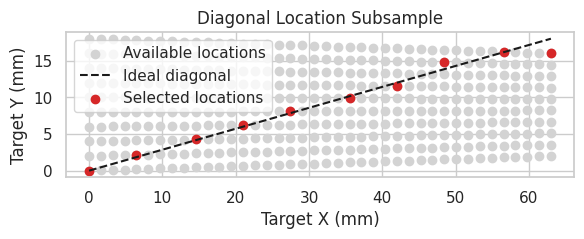

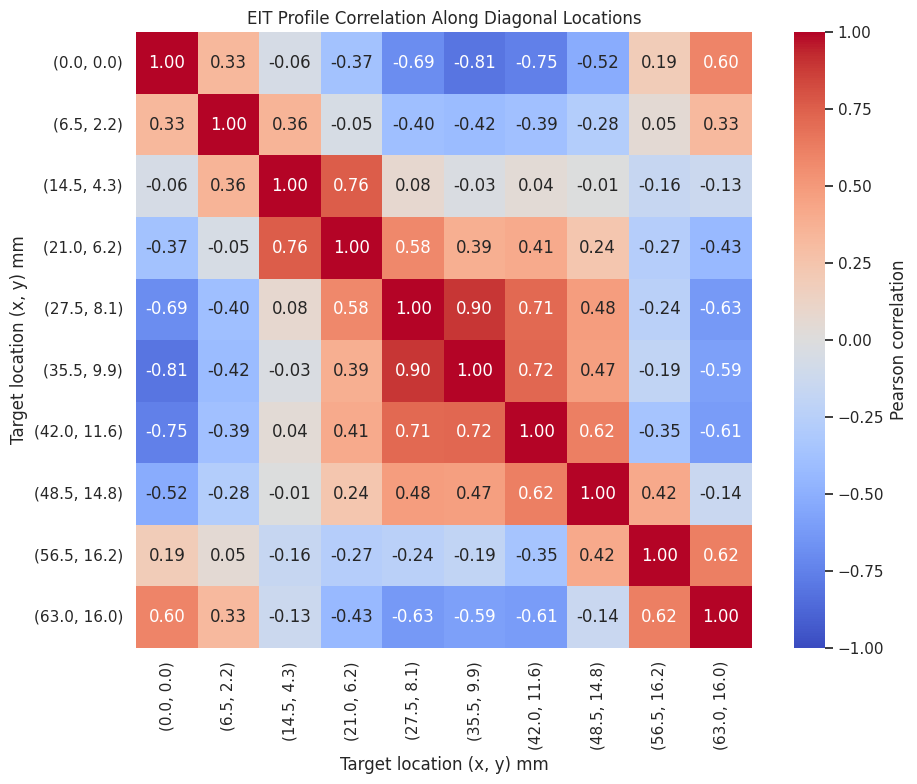

In [12]:
LOCATION_SAMPLE_SIZE = 10
location_cols = ["target_x_mm", "target_y_mm"]

# Average repeated measurements at the same target location into one EIT profile.
location_eit_profiles = (
    df_model
    .groupby(location_cols, as_index=False)[eit_cols]
    .mean()
)

if len(location_eit_profiles) < LOCATION_SAMPLE_SIZE:
    raise ValueError(
        f"Need at least {LOCATION_SAMPLE_SIZE} unique locations, "
        f"but only found {len(location_eit_profiles)}."
    )

x_min, x_max = location_eit_profiles["target_x_mm"].min(), location_eit_profiles["target_x_mm"].max()
y_min, y_max = location_eit_profiles["target_y_mm"].min(), location_eit_profiles["target_y_mm"].max()

# Define an ideal corner-to-corner diagonal, then choose the nearest measured location
# to each evenly spaced point. This keeps the matrix spatially ordered.
diagonal_targets = pd.DataFrame({
    "target_x_mm": np.linspace(x_min, x_max, LOCATION_SAMPLE_SIZE),
    "target_y_mm": np.linspace(y_min, y_max, LOCATION_SAMPLE_SIZE),
})

selected_indices = []
available_indices = set(location_eit_profiles.index)
for _, target in diagonal_targets.iterrows():
    available = location_eit_profiles.loc[list(available_indices), location_cols]
    distances = np.sqrt(
        (available["target_x_mm"] - target["target_x_mm"]) ** 2
        + (available["target_y_mm"] - target["target_y_mm"]) ** 2
    )
    nearest_idx = distances.idxmin()
    selected_indices.append(nearest_idx)
    available_indices.remove(nearest_idx)

sampled_location_eit_profiles = (
    location_eit_profiles
    .loc[selected_indices]
    .reset_index(drop=True)
)

location_labels = sampled_location_eit_profiles.apply(
    lambda row: f"({row['target_x_mm']:.1f}, {row['target_y_mm']:.1f})",
    axis=1,
)

# Columns are sampled locations; rows are EIT channels. Correlating columns compares locations.
eit_by_location = sampled_location_eit_profiles[eit_cols].T
eit_by_location.columns = location_labels
location_correlation_matrix = eit_by_location.corr(method="pearson")

print("Diagonal target locations used for nearest-neighbour subsampling:")
display(diagonal_targets)

print("Selected measured target locations:")
display(sampled_location_eit_profiles[location_cols])

print("Corresponding EIT profiles preview:")
display(sampled_location_eit_profiles[location_cols + eit_cols[:10]])

print("Correlation matrix between diagonal locations:")
display(location_correlation_matrix)

plt.figure(figsize=(6, 6))
plt.gca().set_aspect("equal", adjustable="box")
plt.scatter(
    location_eit_profiles["target_x_mm"],
    location_eit_profiles["target_y_mm"],
    color="lightgray",
    label="Available locations",
)
plt.plot(
    diagonal_targets["target_x_mm"],
    diagonal_targets["target_y_mm"],
    "k--",
    label="Ideal diagonal",
)
plt.scatter(
    sampled_location_eit_profiles["target_x_mm"],
    sampled_location_eit_profiles["target_y_mm"],
    color="tab:red",
    label="Selected locations",
)
plt.xlabel("Target X (mm)")
plt.ylabel("Target Y (mm)")
plt.title("Diagonal Location Subsample")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(
    location_correlation_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    square=True,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("EIT Profile Correlation Along Diagonal Locations")
plt.xlabel("Target location (x, y) mm")
plt.ylabel("Target location (x, y) mm")
plt.tight_layout()
plt.show()


## 6. Modelling Dataset and Split

Only contact rows are used for prediction. Baseline rows have already been consumed during subtraction, so they should not enter the model directly.


In [13]:
from sklearn.model_selection import train_test_split

X = df_model.loc[:, eit_cols].reset_index(drop=True)
Y = df_model.loc[:, ["target_x_mm", "target_y_mm"]].reset_index(drop=True)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
display(Y.head())
display(X.head())

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=44,
)

X_train.shape, X_test.shape


X shape: (24000, 208)
Y shape: (24000, 2)


,target_x_mm,target_y_mm
0,12.923077,13.772080
1,19.384615,15.521368
2,17.769231,15.561254
3,16.153846,11.829060
4,35.538462,8.125356


,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,eit_55,eit_56,eit_57,eit_58,eit_59,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,0.00004,0.00007,0.00008,0.00004,0.000065,0.000233,0.000045,-0.000097,-0.000283,-0.000219,-0.000214,-0.000175,-0.000157,0.00002,0.00001,0.00003,0.000060,-0.000031,0.000104,-0.000065,-0.000197,-0.000156,-0.000298,-0.000173,-0.000136,0.00025,0.00005,-0.00008,-0.000186,-0.000190,-0.000154,-0.000131,-0.000312,-0.000222,-0.000322,-0.000219,-0.000214,0.00037,0.00021,0.00020,0.000052,0.000064,0.000060,0.000099,-0.000112,-0.000170,0.000079,0.000062,-0.000009,0.000016,-0.00004,-0.00014,0.000114,-0.000165,0.000245,-0.000055,-0.000143,-0.000052,0.000162,0.000075,...,-0.000184,-0.000053,-0.000101,0.000064,0.000020,-0.000383,-0.000450,-0.000872,-0.00045,0.000495,-0.000106,-0.000245,-0.000212,0.000193,0.000014,0.000352,0.000216,-0.000014,-0.000284,-0.000221,-0.000616,0.000530,-0.000184,-0.000161,-0.000205,-0.000051,0.000013,0.000229,0.000237,0.000119,0.000091,0.000025,-0.000760,-0.00010,-0.000213,-0.000245,-0.000225,-0.000047,-0.000286,-0.000046,0.000126,0.000128,-0.000306,-0.000198,0.000093,0.00012,-0.00060,0.00014,0.00028,0.000163,0.000277,0.000127,0.000005,0.000244,0.000420,0.000423,-0.000080,-0.000013,0.000263,0.000442
1,-0.00014,-0.00033,-0.00019,-0.00003,0.000141,0.000076,-0.000047,-0.000023,-0.000704,-0.000991,-0.000288,-0.000125,0.000037,-0.00020,-0.00004,-0.00007,-0.000011,0.000014,-0.000148,0.000056,-0.000716,-0.001168,-0.000221,-0.000036,-0.000319,0.00001,-0.00005,-0.00007,0.000218,0.000023,0.000137,0.000125,-0.001019,-0.001057,-0.000253,-0.000231,-0.000225,-0.00012,-0.00007,0.00004,-0.000022,-0.000191,-0.000150,-0.000115,-0.000807,-0.000858,-0.000244,-0.000141,-0.000147,-0.000059,-0.00010,-0.00011,-0.000177,0.000032,-0.000061,-0.000022,-0.000772,-0.001002,-0.000113,-0.000194,...,-0.000815,-0.000890,-0.000810,-0.000491,-0.000567,-0.000326,-0.000310,-0.000355,-0.00033,0.000003,-0.000193,-0.000197,-0.000283,-0.000212,-0.000222,-0.000267,-0.000070,-0.000053,0.000068,0.000157,-0.001878,-0.000105,-0.000320,-0.000169,-0.000210,-0.000179,-0.000312,-0.000118,-0.000484,-0.000002,0.000203,0.000027,-0.001659,-0.00172,-0.000119,-0.000090,-0.000196,-0.000233,-0.000218,-0.000128,-0.000180,-0.000104,0.000019,-0.000088,0.000152,-0.00158,-0.00042,-0.00008,-0.00023,-0.000065,-0.000068,0.000068,-0.000067,-0.000038,-0.000229,-0.000024,-0.000781,-0.000857,-0.000167,-0.000139
2,-0.00007,-0.00012,-0.00009,-0.00028,0.000065,0.000087,-0.000135,-0.000074,-0.001283,-0.001482,-0.000409,-0.000398,-0.000203,-0.00018,-0.00003,-0.00021,-0.000026,0.000186,-0.000091,-0.000121,-0.001095,-0.001033,-0.000429,-0.000249,-0.000410,0.00001,-0.00019,-0.00016,-0.000061,-0.000242,-0.000174,-0.000035,-0.001181,-0.001157,-0.000339,-0.000363,-0.000384,-0.00006,-0.00030,-0.00018,-0.000237,-0.000011,-0.000085,-0.000208,-0.001219,-0.001150,-0.000039,-0.000023,-0.000198,0.000016,0.00003,-0.00004,-0.000174,0.000117,-0.000103,0.000038,-0.001016,-0.001304,-0.000238,-0.000184,...,-0.001101,-0.001127,-0.000940,-0.000807,-0.000726,-0.000385,-0.000729,-0.001031,-0.00078,-0.000026,-0.000302,-0.000569,-0.000372,0.000064,-0.000005,-0.000108,-0.000097,0.000042,0.000042,-0.000050,-0.002379,0.000020,-0.000205,-0.0

((19200, 208), (4800, 208))

In [14]:
X_train.head()

,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,eit_55,eit_56,eit_57,eit_58,eit_59,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
816,-0.00010,-0.00004,0.00023,0.00002,-0.000969,0.000420,0.000333,0.000362,-0.000177,-0.000183,-0.000334,-0.000303,-0.000052,-0.00005,0.00004,0.00025,-0.000844,0.000528,0.000428,0.000381,-0.000074,-0.000035,-0.000251,-0.000026,-0.000201,-0.00016,0.00010,0.00039,-0.001005,0.000642,0.000481,0.000428,-0.000208,-0.000365,-0.000140,-0.000198,-0.000216,-0.00009,-0.00019,0.00008,-0.000858,0.000322,0.000343,0.000240,-0.000142,-0.000091,-0.000112,-0.000080,-0.000120,7.000000e-06,-0.00011,-0.00011,-0.000920,0.000276,0.000175,0.000237,-0.000202,-0.000181,-0.000242,-0.000126,...,-0.000382,-0.000160,-0.000304,-0.000217,-0.000678,0.000506,0.000194,0.000291,-0.00024,-0.000200,-0.000219,-0.000061,-0.000010,-0.000172,-0.000275,-0.000141,-0.000693,-0.000558,0.000103,0.000166,-0.000093,-0.000012,-0.000215,-0.000189,-0.000372,-0.000195,-0.000400,-0.000084,-0.000942,-0.000600,0.000164,0.000211,-0.000086,-0.00020,-0.000353,-0.000143,-0.000243,-0.000325,-0.000355,-0.000164,-0.000628,-0.000331,0.000115,0.000420,0.000095,-0.00022,-0.00018,-0.00003,-0.00008,-7.700000e-05,-0.000191,-0.000175,-0.000931,0.000790,0.000187,0.000426,-0.000167,0.000087,-0.000036,-0.000076
13499,-0.00020,-0.00045,-0.00040,-0.00037,0.000094,-0.000374,-0.000301,-0.000555,-0.001118,-0.000604,-0.002503,-0.002448,-0.000650,-0.00047,-0.00040,-0.00032,0.000201,-0.000318,-0.000481,-0.000640,-0.000865,-0.000618,-0.002312,-0.002126,-0.000521,0.00050,-0.00063,-0.00048,-0.000037,-0.000504,-0.000341,-0.000436,-0.000937,-0.000503,-0.002220,-0.002264,-0.000383,0.00058,-0.00024,-0.00034,-0.000143,-0.000035,-0.000308,-0.000420,-0.000447,-0.000209,-0.001410,-0.001445,-0.000384,1.000000e-06,-0.00043,-0.00044,0.000168,0.000359,0.000333,-0.000519,-0.000496,-0.000114,-0.001275,-0.001434,...,-0.000442,-0.000241,-0.000118,0.000032,0.000393,0.000609,-0.000112,-0.000932,-0.00278,0.000118,-0.002417,-0.002266,-0.002193,-0.001364,-0.001401,-0.000624,-0.000147,0.002618,0.002535,0.004625,0.002701,-0.000030,-0.002347,-0.002183,-0.002176,-0.001334,-0.001414,-0.000665,-0.000237,0.002531,0.002358,0.004468,0.003474,-0.00203,-0.000652,-0.000538,-0.000497,-0.000269,-0.000303,-0.000216,-0.000007,0.000452,0.000498,0.000708,0.000445,-0.00099,-0.00268,0.00057,0.00056,1.000000e-06,-0.000150,0.000022,0.000008,-0.000050,-0.000182,-0.000024,-0.000544,-0.000103,0.000120,0.000064
12100,-0.00117,-0.00108,-0.00128,-0.00168,-0.000453,-0.000226,-0.000469,-0.000624,-0.000309,-0.000907,-0.000600,-0.000492,-0.000456,-0.00125,-0.00127,-0.00178,-0.000655,-0.000125,-0.000219,-0.000448,-0.000368,-0.000876,-0.000665,-0.000611,-0.000644,0.00004,-0.00132,-0.00188,-0.000654,-0.000259,-0.000511,-0.000596,-0.000529,-0.001228,-0.000882,-0.000860,-0.000904,-0.00040,-0.00122,-0.00181,-0.001411,0.000104,0.000221,-0.000271,-0.000320,-0.001520,-0.001202,-0.001192,-0.001214,-4.830000e-04,-0.00104,-0.00138,-0.001405,0.000058,0.000125,-0.000575,-0.000668,-0.001844,-0.001634,-0.001571,...,-0.001040,-0.001329,-0.001698,-0.001571,-0.000772,-0.000112,0.001047,0.000568,-0.00170,-0.000337,-0.000488,-0.000689,-0.000844,-0.001126,-0.001467,-0.001878,-0.001071,-0.001589,-0.001136,

In [15]:
Y_train.head()

,target_x_mm,target_y_mm
816,32.307692,2.797721
13499,9.692308,13.829060
12100,46.846154,1.487179
14705,56.538462,6.598291
7764,25.846154,9.908832


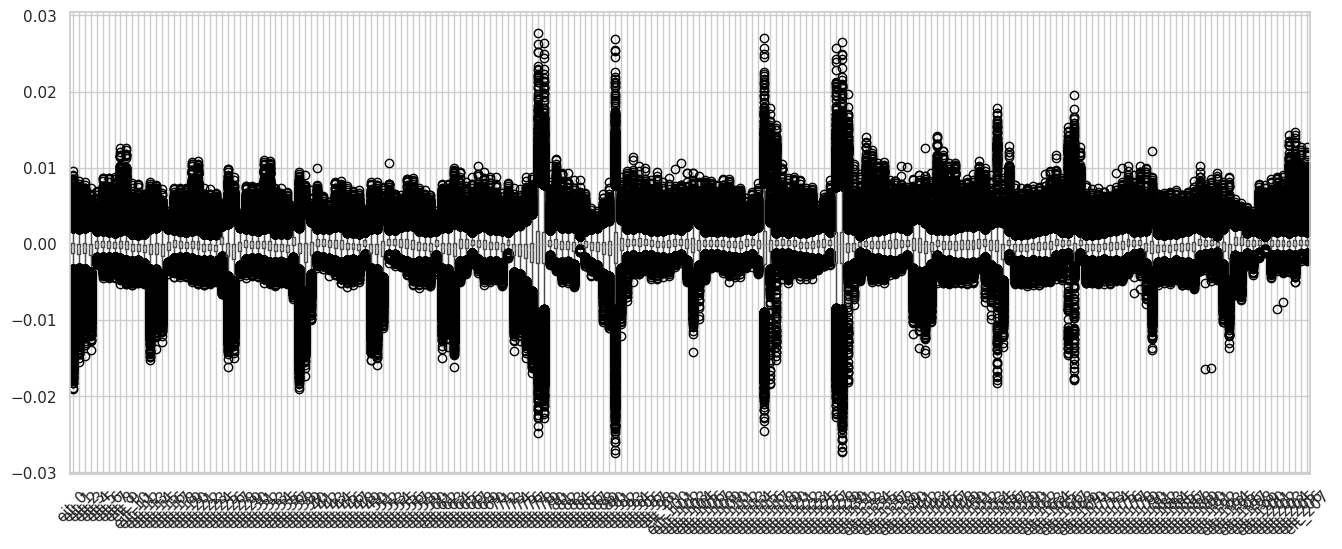

In [16]:
X_train.boxplot(figsize=(16, 6))
plt.xticks(rotation=45)
plt.show()

## 7. Feature Scaling

Fit scaling parameters on `X_train` only so the test split remains genuinely held out.


In [17]:
# Fit the scaler on the training split only, then apply the same transform to test data.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


,mean,std
eit_0,-6.661338e-18,1.0
eit_1,7.401487e-18,1.0
eit_2,7.771561e-17,1.0
eit_3,-1.628327e-17,1.0
eit_4,-1.276756e-17,1.0


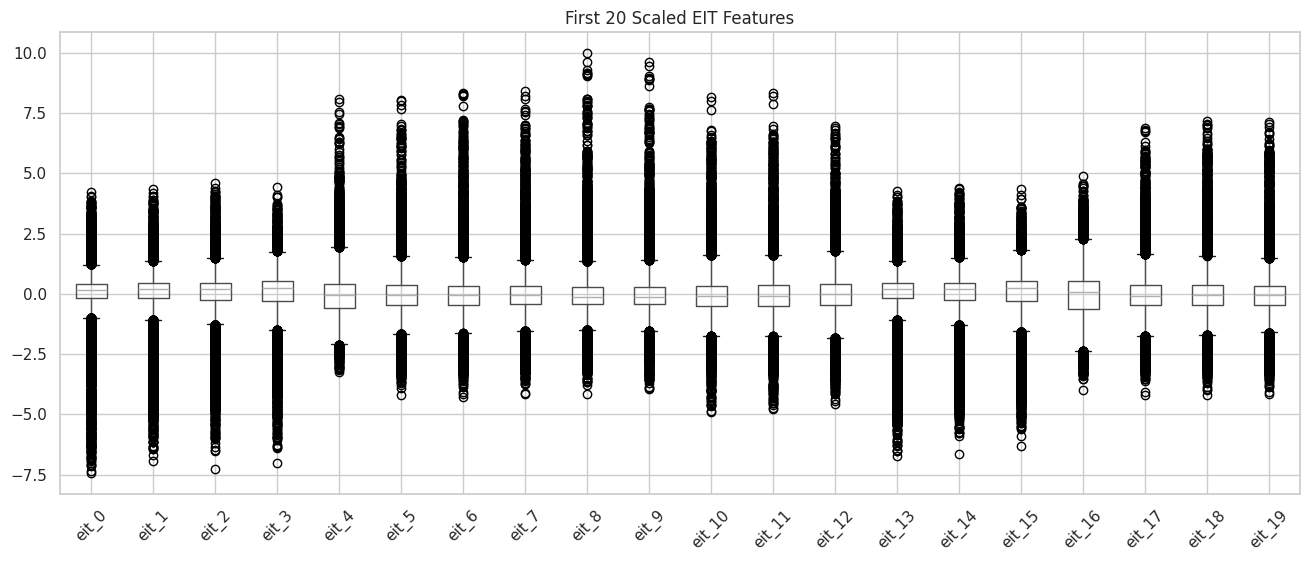

In [18]:
# Convert the scaled arrays back to DataFrames for inspection.
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

scaled_summary = pd.DataFrame({
    "mean": X_train_scaled_df.mean(),
    "std": X_train_scaled_df.std(ddof=0),
})
display(scaled_summary.head())

X_train_scaled_df.iloc[:, :20].boxplot(figsize=(16, 6))
plt.xticks(rotation=45)
plt.title("First 20 Scaled EIT Features")
plt.show()

## 8. Linear Regression Baseline

Start with a simple multi-output linear model. Its predictions and errors are used again in the diagnostic plots at the end.


In [19]:
from sklearn.linear_model import LinearRegression

# Baseline multi-output regression: EIT channels predict x/y location in mm.
model = LinearRegression()
model.fit(X_train_scaled, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2, 208)","[[-0.79,-5.46, 4.01,..., 1.45,-5.95, 1.8 ], [-1.33, 1.15,-0.26,...,-1.1 , 1.19,-1.54]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](2,)","[31.43, 8.98]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,208
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,208
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](208,)","[998.35,863.95,563.32,..., 5.38, 5.22, 4.74]"


In [20]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict held-out test points and inspect coordinate-wise regression quality.
y_pred = model.predict(X_test_scaled)
y_pred_df = pd.DataFrame(y_pred, columns=Y.columns, index=Y_test.index)

mse = mean_squared_error(Y_test, y_pred, multioutput="raw_values")
r2 = r2_score(Y_test, y_pred, multioutput="raw_values")
rmse = np.sqrt(mse)

target_names = Y.columns
metrics_df = pd.DataFrame({
    "Target": target_names,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2,
})

print("Coordinate Regression Metrics:")
display(metrics_df)
display(y_pred_df.head())


Coordinate Regression Metrics:


,Target,MSE,RMSE,R2 Score
0,target_x_mm,70.274968,8.383017,0.802233
1,target_y_mm,7.231969,2.689232,0.728234


,target_x_mm,target_y_mm
4683,46.031937,7.398526
20579,41.156798,7.301358
18150,20.274313,2.944289
10011,44.516704,4.319284
19393,-4.624715,14.828800


In [21]:
# Summarise linear-model localisation error as Euclidean x/y distance in millimetres.
position_error_mm = np.sqrt(
    (Y_test["target_x_mm"].to_numpy() - y_pred[:, 0]) ** 2
    + (Y_test["target_y_mm"].to_numpy() - y_pred[:, 1]) ** 2
)

print(f"Mean position error: {position_error_mm.mean():.2f} mm")
print(f"Median position error: {np.median(position_error_mm):.2f} mm")
print(f"90th percentile position error: {np.percentile(position_error_mm, 90):.2f} mm")


Mean position error: 7.20 mm
Median position error: 6.02 mm
90th percentile position error: 14.06 mm


## 9. Model Comparison

Run a small leaderboard of candidate localisation models using the same train/test split. Toggle `RUN_SLOW_MODELS` if you want to include the slower neural-network and SVR options.


In [22]:
# Compare multiple localisation models on the same train/test split.
# Slow models are disabled by default so the notebook stays responsive.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from time import perf_counter

RUN_SLOW_MODELS = False

model_candidates = [
    (
        "Linear Regression",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        True,
    ),
    (
        "RidgeCV",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 4, 20))),
        ]),
        True,
    ),
    (
        "Elastic Net",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", MultiOutputRegressor(
                ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=20000, random_state=0)
            )),
        ]),
        RUN_SLOW_MODELS,
    ),
    (
        "PLS Regression",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression(n_components=10)),
        ]),
        True,
    ),
    (
        "PCA + Ridge",
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=30, random_state=0)),
            ("model", RidgeCV(alphas=np.logspace(-3, 4, 20))),
        ]),
        True,
    ),
    (
        "Random Forest",
        RandomForestRegressor(
            n_estimators=250,
            min_samples_leaf=2,
            random_state=0,
            n_jobs=-1,
        ),
        True,
    ),
    (
        "Hist Gradient Boosting",
        MultiOutputRegressor(
            HistGradientBoostingRegressor(
                max_iter=300,
                learning_rate=0.05,
                l2_regularization=0.01,
                random_state=0,
            )
        ),
        True,
    ),
    (
        "MLP Neural Network",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                alpha=1e-4,
                learning_rate_init=1e-3,
                early_stopping=True,
                max_iter=500,
                random_state=0,
            )),
        ]),
        True,
    ),
    (
        "SVR RBF",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", MultiOutputRegressor(
                SVR(kernel="rbf", C=10, epsilon=0.5, gamma="scale")
            )),
        ]),
        RUN_SLOW_MODELS,
    ),
]


In [23]:
def evaluate_localisation_model(name, estimator, X_train, X_test, Y_train, Y_test):
    start = perf_counter()
    estimator.fit(X_train, Y_train)
    y_pred = estimator.predict(X_test)
    elapsed_s = perf_counter() - start

    y_pred = np.asarray(y_pred)
    mae = mean_absolute_error(Y_test, y_pred, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(Y_test, y_pred, multioutput="raw_values"))
    r2 = r2_score(Y_test, y_pred, multioutput="raw_values")
    position_error_mm = np.sqrt(
        (Y_test["target_x_mm"].to_numpy() - y_pred[:, 0]) ** 2
        + (Y_test["target_y_mm"].to_numpy() - y_pred[:, 1]) ** 2
    )

    per_target = pd.DataFrame({
        "Model": name,
        "Target": Y_test.columns,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "Fit + predict time (s)": elapsed_s,
    })
    summary = {
        "Model": name,
        "Mean position error (mm)": position_error_mm.mean(),
        "Median position error (mm)": np.median(position_error_mm),
        "90th percentile error (mm)": np.percentile(position_error_mm, 90),
        "Mean coordinate RMSE": rmse.mean(),
        "Mean coordinate R2": r2.mean(),
        "Fit + predict time (s)": elapsed_s,
    }
    return per_target, summary, y_pred, estimator

all_metric_rows = []
all_summary_rows = []
model_predictions = {}
estimator_objects = {}

for name, estimator, enabled in model_candidates:
    if not enabled:
        print(f"Skipping {name}. Set RUN_SLOW_MODELS = True to include it.")
        continue

    print(f"Training {name}...")
    per_target_metrics, summary_metrics, y_pred_model, trained_estimator = evaluate_localisation_model(
        name,
        estimator,
        X_train,
        X_test,
        Y_train,
        Y_test,
    )
    all_metric_rows.append(per_target_metrics)
    all_summary_rows.append(summary_metrics)
    model_predictions[name] = y_pred_model
    estimator_objects[name] = trained_estimator

model_metrics_df = pd.concat(all_metric_rows, ignore_index=True)
model_summary_df = pd.DataFrame(all_summary_rows).sort_values("Mean position error (mm)")

print("Model leaderboard, sorted by mean x/y position error:")
display(model_summary_df)

print("Per-target metrics:")
display(model_metrics_df.sort_values(["Target", "RMSE"]))


Training Linear Regression...
Training RidgeCV...
Skipping Elastic Net. Set RUN_SLOW_MODELS = True to include it.
Training PLS Regression...
Training PCA + Ridge...
Training Random Forest...
Training Hist Gradient Boosting...
Training MLP Neural Network...
Skipping SVR RBF. Set RUN_SLOW_MODELS = True to include it.
Model leaderboard, sorted by mean x/y position error:


,Model,Mean position error (mm),Median position error (mm),90th percentile error (mm),Mean coordinate RMSE,Mean coordinate R2,Fit + predict time (s)
6,MLP Neural Network,1.757375,1.433522,3.218583,1.588086,0.965559,15.307742
4,Random Forest,2.347129,1.495084,4.556805,2.586597,0.931881,38.466720
5,Hist Gradient Boosting,2.598804,1.932974,5.022955,2.384911,0.941113,2.765100
1,RidgeCV,7.202585,6.031648,14.041483,5.534388,0.765414,1.084888
0,Linear Regression,7.203469,6.017902,14.056251,5.536124,0.765234,0.163061
2,PLS Regression,8.283672,7.181488,15.725223,6.248418,0.709133,0.704649
3,PCA + Ridge,8.556478,7.118515,16.682252,6.485198,0.698119,0.163157


Per-target metrics:


,Model,Target,MAE,RMSE,R2 Score,Fit + predict time (s)
12,MLP Neural Network,target_x_mm,1.339359,1.929499,0.989523,15.307742
10,Hist Gradient Boosting,target_x_mm,2.122833,3.237066,0.970511,2.765100
8,Random Forest,target_x_mm,1.845233,3.532850,0.964876,38.466720
2,RidgeCV,target_x_mm,6.587625,8.380820,0.802337,1.084888
0,Linear Regression,target_x_mm,6.588127,8.383017,0.802233,0.163061
4,PLS Regression,target_x_mm,7.612475,9.557475,0.742937,0.704649
6,PCA + Ridge,target_x_mm,7.910267,10.055980,0.715422,0.163157
13,MLP Neural Network,target_y_mm,0.869976,1.246673,0.941596,15.307742
11,Hist Gradient Boosting,target_y_mm,1.076842,1.532755,0.911715,2.765100
9,Random Forest,target_y_mm,1.062197,1.640343,0.898887,38.466720


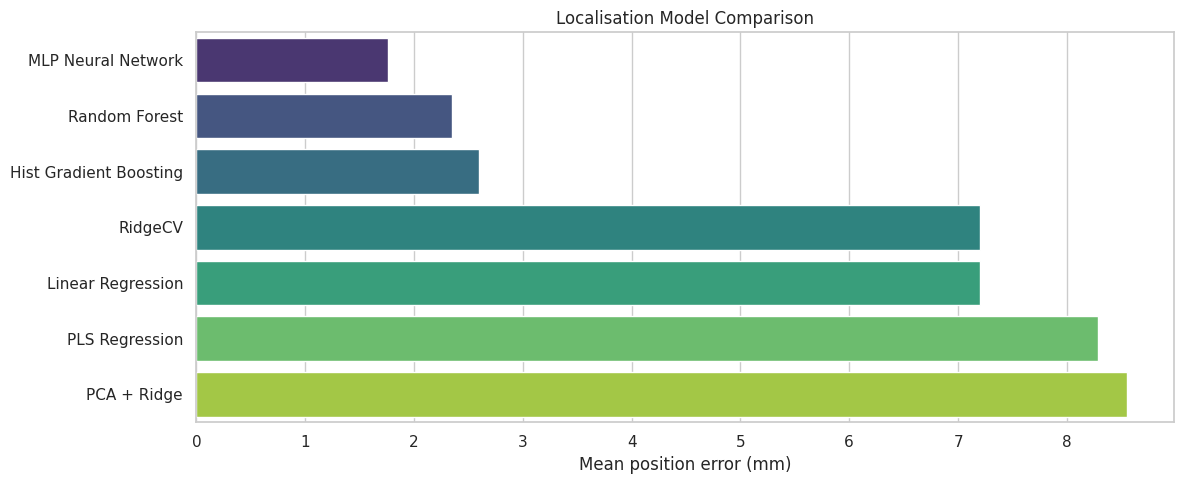

Best model 'MLP Neural Network' saved to disk.


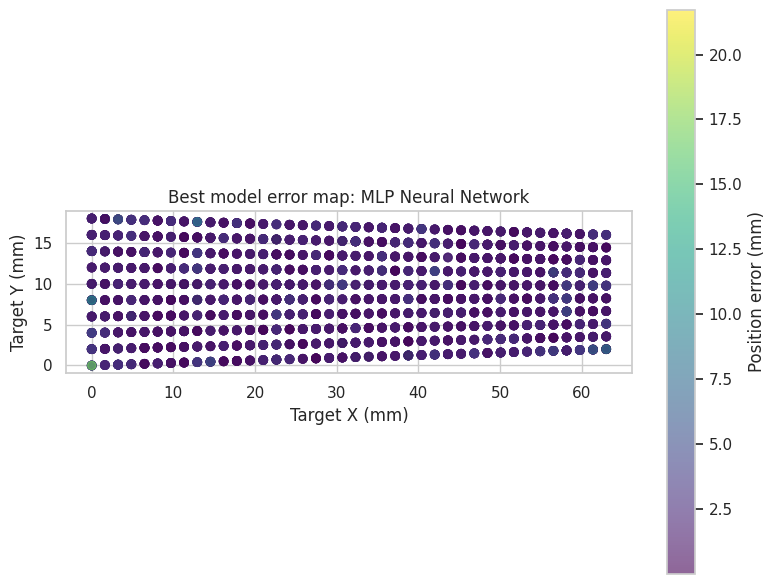

In [28]:
# Visual comparison of localisation error across models.
plt.figure(figsize=(12, 5))
sns.barplot(
    data=model_summary_df,
    x="Mean position error (mm)",
    y="Model",
    hue="Model",
    dodge=False,
    legend=False,
    palette="viridis",
)
plt.xlabel("Mean position error (mm)")
plt.ylabel("")
plt.title("Localisation Model Comparison")
plt.tight_layout()
plt.show()

best_model_name = model_summary_df.iloc[0]["Model"]
best_model = estimator_objects[best_model_name]
#Save the best model for future use
import joblib
joblib.dump(best_model, f"best_localisation_model_{best_model_name.replace(' ', '_')}.joblib")
print(f"Best model '{best_model_name}' saved to disk.")
best_y_pred = model_predictions[best_model_name]
best_position_error_mm = np.sqrt(
    (Y_test["target_x_mm"].to_numpy() - best_y_pred[:, 0]) ** 2
    + (Y_test["target_y_mm"].to_numpy() - best_y_pred[:, 1]) ** 2
)

plt.figure(figsize=(8, 6))
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Target X (mm)")
plt.ylabel("Target Y (mm)")
scatter = plt.scatter(
    Y_test["target_x_mm"],
    Y_test["target_y_mm"],
    c=best_position_error_mm,
    cmap="viridis",
    alpha=0.6,
)
plt.colorbar(scatter, label="Position error (mm)")
plt.title(f"Best model error map: {best_model_name}")
plt.tight_layout()
#export as a vector pdf
plt.savefig(f"best_model_error_map_{best_model_name.replace(' ', '_')}.pdf", format="pdf")
plt.show()



## 10. Linear Baseline Diagnostics

These plots focus on the first linear regression baseline (`model` / `y_pred`) so it is easy to compare the simple reference model against the model leaderboard above.


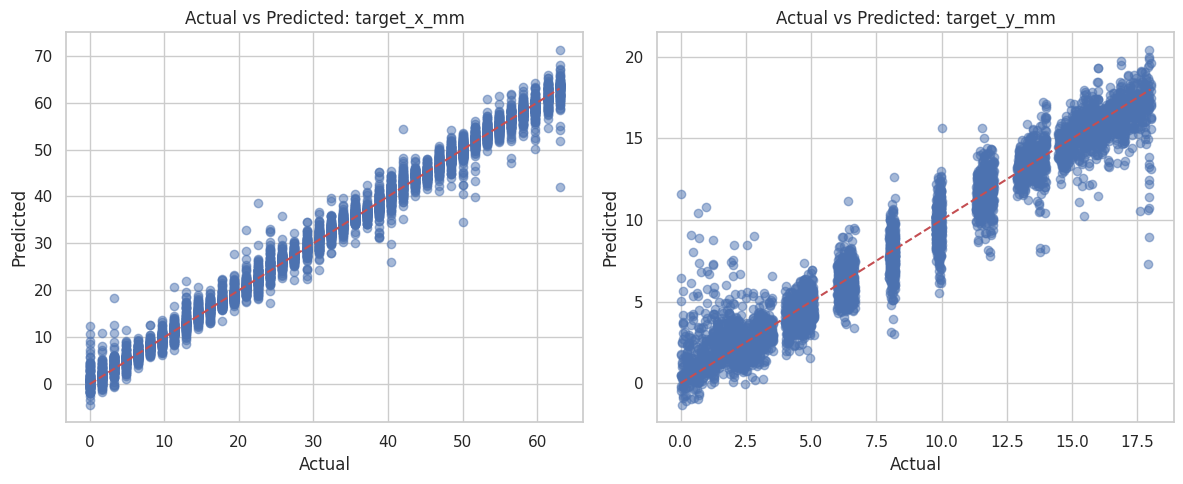

In [25]:
# Linear baseline: actual vs predicted coordinates.
plt.figure(figsize=(12, 5))

for i, col in enumerate(target_names):
    plt.subplot(1, 2, i + 1)
    plt.scatter(Y_test.iloc[:, i], best_y_pred[:, i], alpha=0.5)
    plt.plot(
        [Y_test.iloc[:, i].min(), Y_test.iloc[:, i].max()],
        [Y_test.iloc[:, i].min(), Y_test.iloc[:, i].max()],
        "r--",
    )
    plt.title(f"Actual vs Predicted: {col}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

plt.tight_layout()
plt.show()


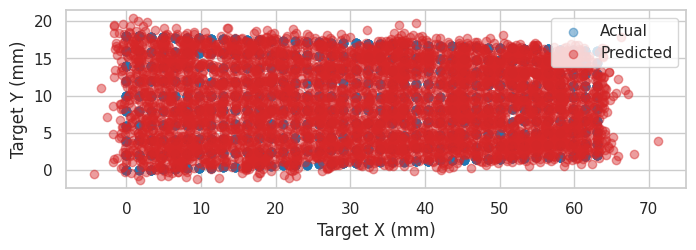

In [26]:
# Linear baseline: actual and predicted test positions on the x/y plane.
plt.figure(figsize=(8, 6))
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Target X (mm)")
plt.ylabel("Target Y (mm)")
plt.scatter(Y_test["target_x_mm"], Y_test["target_y_mm"], color="tab:blue", label="Actual", alpha=0.45)
plt.scatter(best_y_pred[:, 0], best_y_pred[:, 1], color="tab:red", label="Predicted", alpha=0.45)
plt.legend()
plt.show()


/tmp/ipykernel_18189/2319844334.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


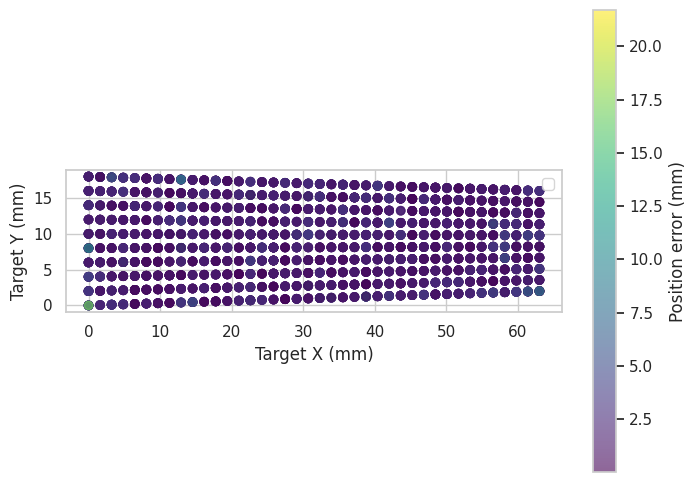

In [27]:
# Linear baseline: test positions coloured by prediction error.
plt.figure(figsize=(8, 6))
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Target X (mm)")
plt.ylabel("Target Y (mm)")
scatter = plt.scatter(
    Y_test["target_x_mm"],
    Y_test["target_y_mm"],
    c=best_position_error_mm,
    cmap="viridis",
    alpha=0.6,
)
# plt.scatter(Y_train["target_x_mm"], Y_train["target_y_mm"], color="red", label="Train", alpha=0.5)
plt.colorbar(scatter, label="Position error (mm)")
plt.legend()
plt.show()
